# 🔬 Pipeline Walkthrough — One Image, Every Step
**From raw satellite image → red boundary contour, nothing skipped.**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 10, 'axes.titleweight': 'bold'})

In [2]:
import os, sys
sys.path.append(os.path.abspath('..'))

In [3]:
from cnn.conv       import convolve
from cnn.activation import relu
from cnn.pooling    import max_pooling
from cnn.cnn_model  import CustomCNN
from utils.preprocess import load_image, to_grayscale, resize_image, normalize_image
from features.statistics import compute_stats

# ── Pick one image ────────────────────────────────────────────────────────────
IMAGE_PATH = os.path.join('..', 'data', 'testcases', '1.png')
print('Image:', IMAGE_PATH)

Image: ..\data\testcases\1.png


---
## STEP 1 — Load Raw Image

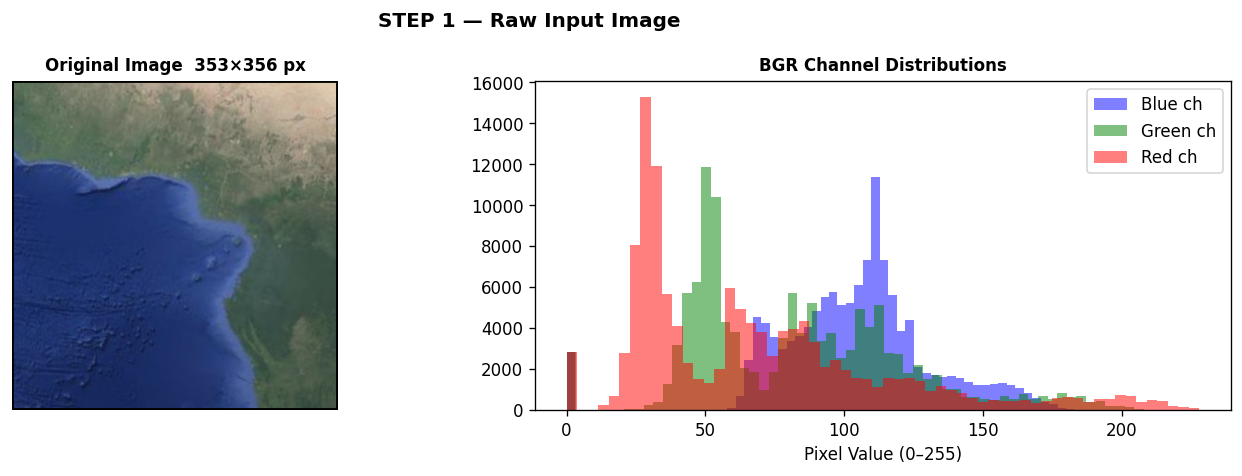

Shape : (356, 353, 3)  |  dtype : uint8  |  value range : [0, 228]


In [4]:
raw_bgr = load_image(IMAGE_PATH)
raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('STEP 1 — Raw Input Image', fontweight='bold')

axes[0].imshow(raw_rgb)
axes[0].set_title(f'Original Image  {raw_bgr.shape[1]}×{raw_bgr.shape[0]} px')
axes[0].axis('off')

# Channel histograms
colors = ['blue', 'green', 'red']
labels = ['Blue ch', 'Green ch', 'Red ch']
for c, (col, lab) in enumerate(zip(colors, labels)):
    axes[1].hist(raw_bgr[:,:,c].flatten(), bins=60, color=col, alpha=0.5, label=lab)
axes[1].set_title('BGR Channel Distributions')
axes[1].set_xlabel('Pixel Value (0–255)')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Shape : {raw_bgr.shape}  |  dtype : {raw_bgr.dtype}  |  value range : [{raw_bgr.min()}, {raw_bgr.max()}]')

---
## STEP 2 — Grayscale Conversion

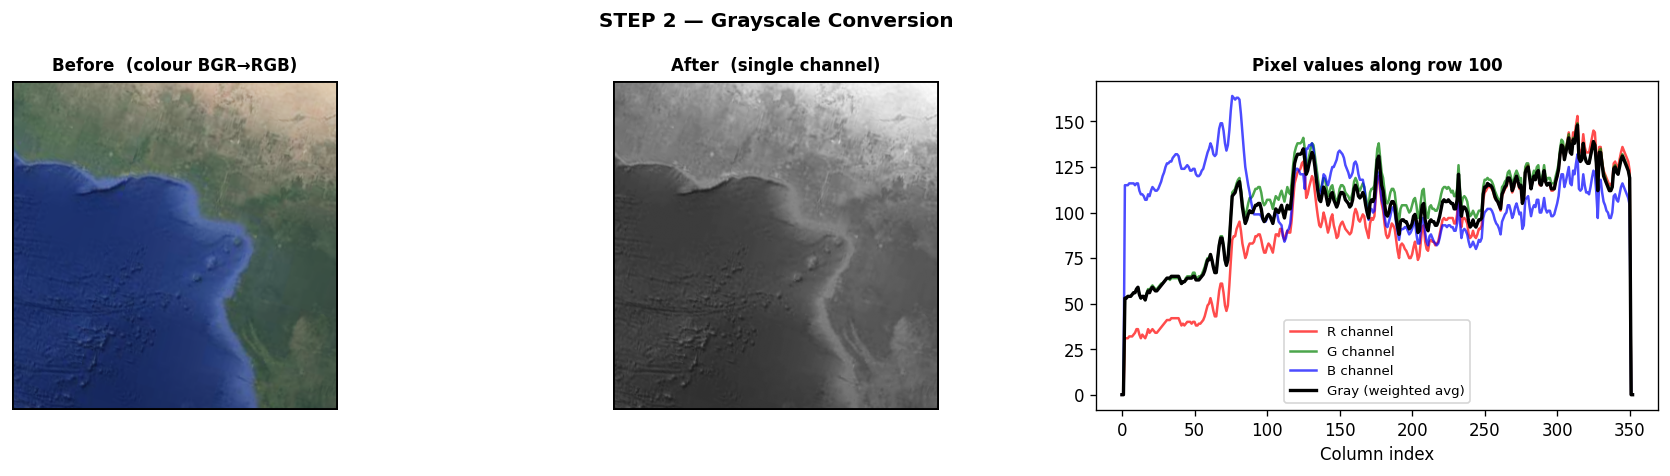

Formula: Gray = 0.299·R + 0.587·G + 0.114·B
Shape: (356, 353, 3) → (356, 353)


In [5]:
gray_raw = to_grayscale(raw_bgr)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('STEP 2 — Grayscale Conversion', fontweight='bold')

axes[0].imshow(raw_rgb)
axes[0].set_title('Before  (colour BGR→RGB)')
axes[0].axis('off')

axes[1].imshow(gray_raw, cmap='gray')
axes[1].set_title('After  (single channel)')
axes[1].axis('off')

# Side-by-side pixel value scan along row 100
row = min(100, gray_raw.shape[0]-1)
axes[2].plot(raw_bgr[row,:,2], color='red',   alpha=0.7, label='R channel')
axes[2].plot(raw_bgr[row,:,1], color='green',  alpha=0.7, label='G channel')
axes[2].plot(raw_bgr[row,:,0], color='blue',   alpha=0.7, label='B channel')
axes[2].plot(gray_raw[row,:],  color='black', linewidth=2, label='Gray (weighted avg)')
axes[2].set_title(f'Pixel values along row {row}')
axes[2].set_xlabel('Column index')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print('Formula: Gray = 0.299·R + 0.587·G + 0.114·B')
print(f'Shape: {raw_bgr.shape} → {gray_raw.shape}')

---
## STEP 3 — Resize to 256×256

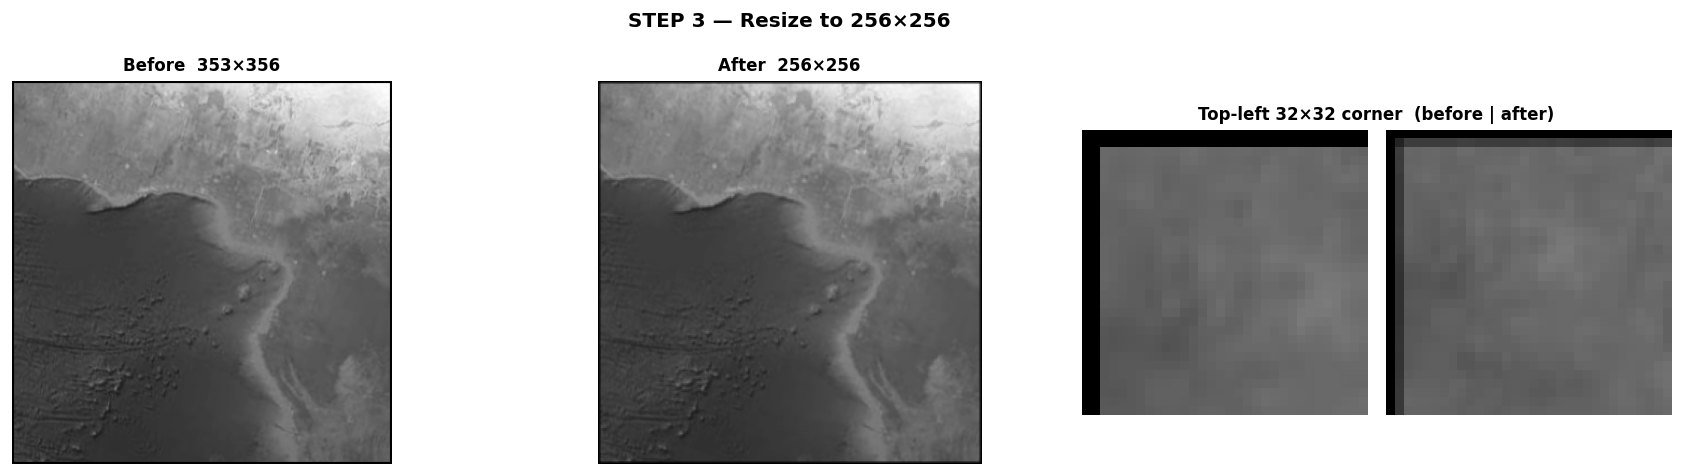

Shape: (356, 353) → (256, 256)


In [6]:
gray_resized = resize_image(gray_raw, (256, 256))
color_resized = cv2.resize(raw_bgr, (256, 256))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('STEP 3 — Resize to 256×256', fontweight='bold')

axes[0].imshow(gray_raw, cmap='gray')
axes[0].set_title(f'Before  {gray_raw.shape[1]}×{gray_raw.shape[0]}')
axes[0].axis('off')

axes[1].imshow(gray_resized, cmap='gray')
axes[1].set_title('After  256×256')
axes[1].axis('off')

# Zoom into a 32×32 region to show pixel-level content before/after
zoom_before = gray_raw[:32, :32]
zoom_after  = gray_resized[:32, :32]
diff_plot   = np.hstack([zoom_before / 255.0, np.ones((32,2)), zoom_after / 255.0])
axes[2].imshow(diff_plot, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Top-left 32×32 corner  (before | after)')
axes[2].axis('off')

plt.tight_layout()
plt.show()
print(f'Shape: {gray_raw.shape} → {gray_resized.shape}')

---
## STEP 4 — Normalise to [0, 1]

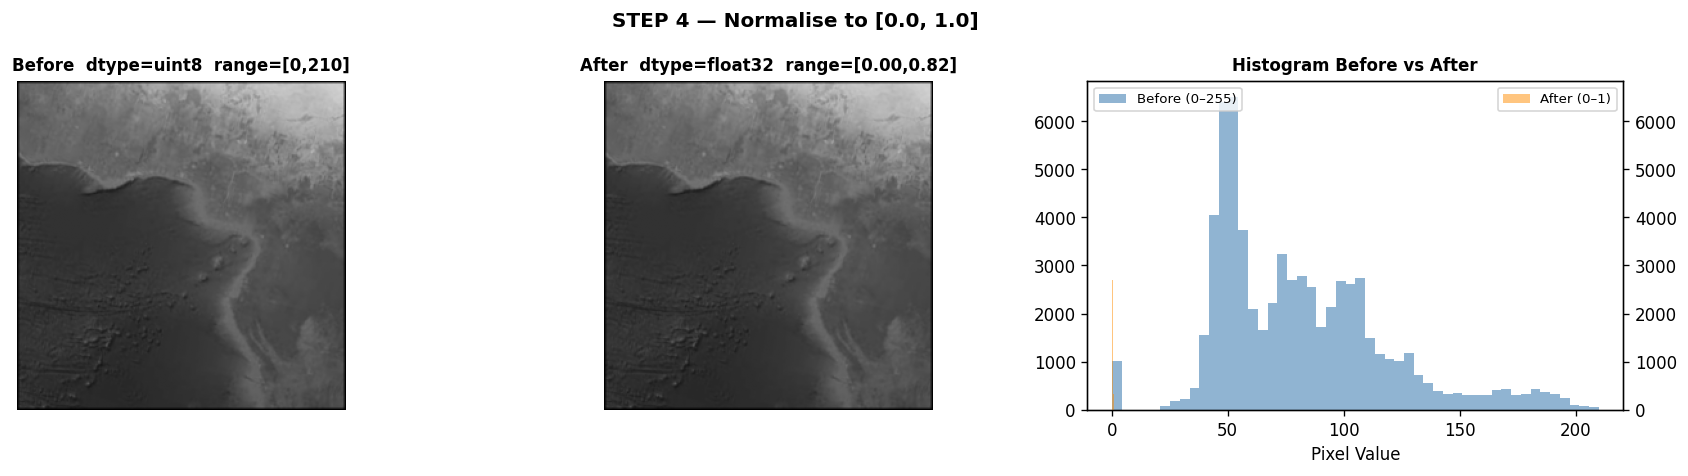

Formula: pixel_norm = pixel / 255.0
Sample pixel: 99 → 0.3882


In [7]:
gray_norm = normalize_image(gray_resized)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('STEP 4 — Normalise to [0.0, 1.0]', fontweight='bold')

axes[0].imshow(gray_resized, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Before  dtype={gray_resized.dtype}  range=[{gray_resized.min()},{gray_resized.max()}]')
axes[0].axis('off')

axes[1].imshow(gray_norm, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'After  dtype={gray_norm.dtype}  range=[{gray_norm.min():.2f},{gray_norm.max():.2f}]')
axes[1].axis('off')

axes[2].hist(gray_resized.flatten(), bins=50, alpha=0.6, color='steelblue', label='Before (0–255)')
ax2 = axes[2].twinx()
ax2.hist(gray_norm.flatten(), bins=50, alpha=0.5, color='darkorange', label='After (0–1)')
axes[2].set_title('Histogram Before vs After')
axes[2].set_xlabel('Pixel Value')
axes[2].legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()
print('Formula: pixel_norm = pixel / 255.0')
print(f'Sample pixel: {gray_resized[50,50]} → {gray_norm[50,50]:.4f}')

---
## STEP 5 — Manual Convolution (from scratch)
We take one **16×16 patch** and apply each kernel manually, showing the numbers.

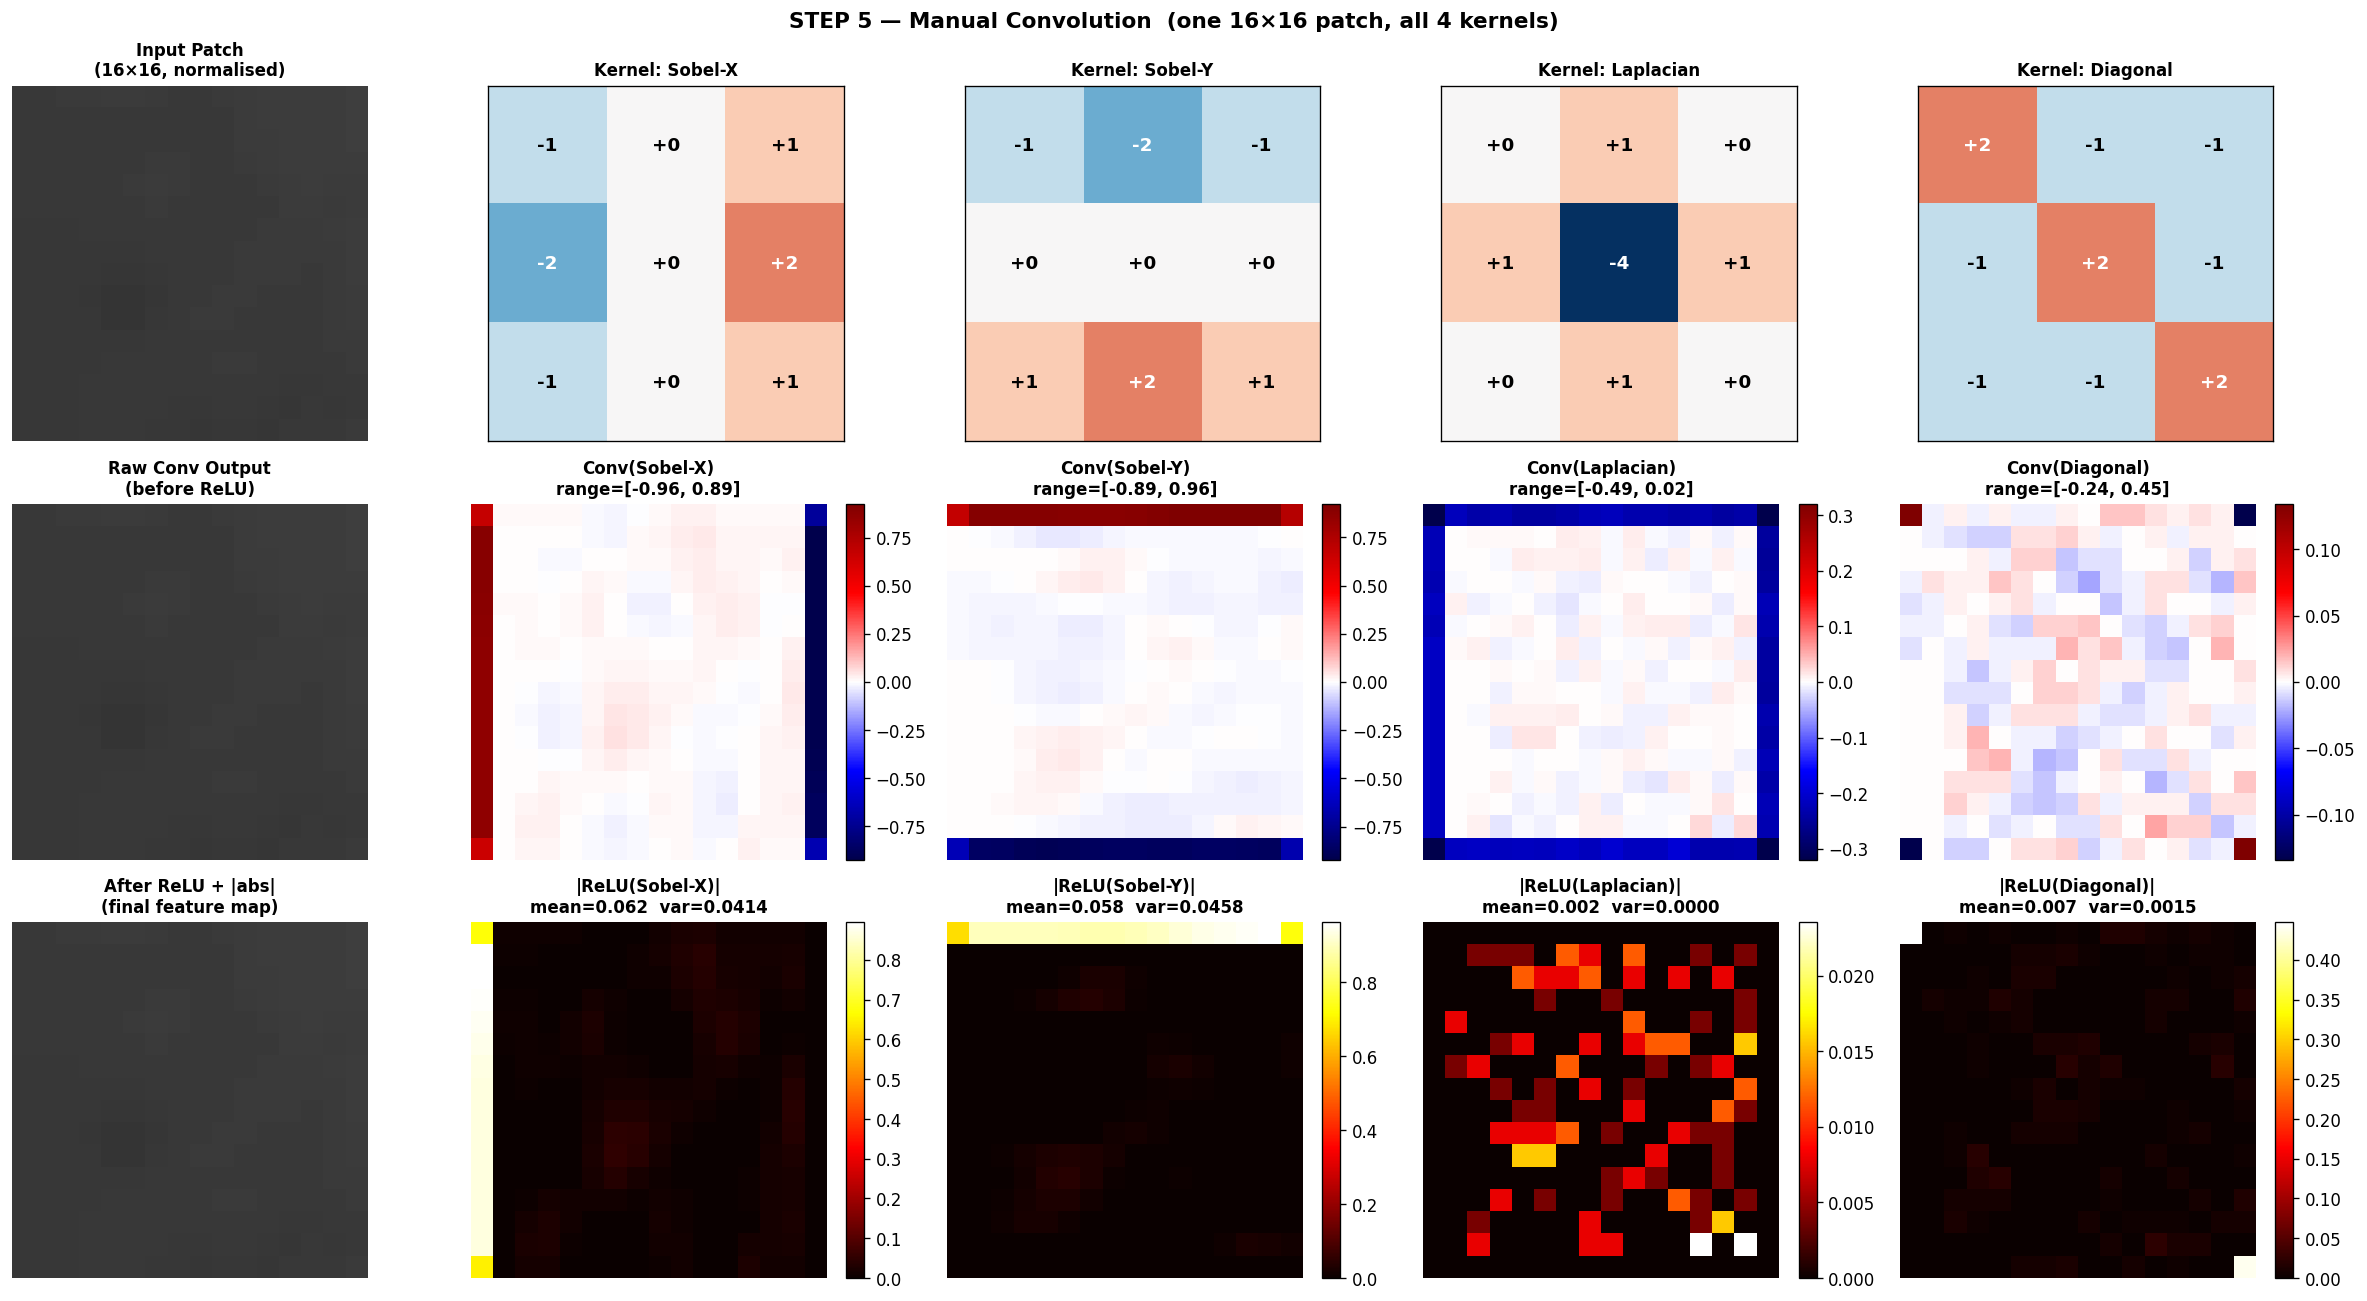

In [8]:
# ── Extract a single 16x16 patch ─────────────────────────────────────────────
PATCH_R, PATCH_C = 100, 100
PATCH_SIZE = 16
patch = gray_norm[PATCH_R:PATCH_R+PATCH_SIZE, PATCH_C:PATCH_C+PATCH_SIZE]

model = CustomCNN()
kernel_names = ['Sobel-X', 'Sobel-Y', 'Laplacian', 'Diagonal']

fig, axes = plt.subplots(3, 5, figsize=(20, 11))
fig.suptitle('STEP 5 — Manual Convolution  (one 16×16 patch, all 4 kernels)', fontweight='bold', fontsize=13)

# Column 0: the patch itself
axes[0,0].imshow(patch, cmap='gray', vmin=0, vmax=1)
axes[0,0].set_title('Input Patch\n(16×16, normalised)')
axes[0,0].axis('off')

axes[1,0].imshow(patch, cmap='gray', vmin=0, vmax=1)
axes[1,0].set_title('Raw Conv Output\n(before ReLU)')
axes[1,0].axis('off')

axes[2,0].imshow(patch, cmap='gray', vmin=0, vmax=1)
axes[2,0].set_title('After ReLU + |abs|\n(final feature map)')
axes[2,0].axis('off')

for col, (kernel, name) in enumerate(zip(model.kernels, kernel_names)):
    # Show kernel values as heatmap
    im = axes[0, col+1].imshow(kernel, cmap='RdBu_r', vmin=-4, vmax=4)
    axes[0, col+1].set_title(f'Kernel: {name}')
    # Annotate each cell with its value
    for r in range(3):
        for c in range(3):
            axes[0, col+1].text(c, r, f'{int(kernel[r,c]):+d}',
                                ha='center', va='center', fontsize=11, fontweight='bold',
                                color='white' if abs(kernel[r,c]) > 1 else 'black')
    axes[0, col+1].set_xticks([]); axes[0, col+1].set_yticks([])

    # Raw convolution output (before ReLU)
    conv_out = convolve(patch, kernel)
    im2 = axes[1, col+1].imshow(conv_out, cmap='seismic',
                                 vmin=-conv_out.std()*3, vmax=conv_out.std()*3)
    axes[1, col+1].set_title(f'Conv({name})\nrange=[{conv_out.min():.2f}, {conv_out.max():.2f}]')
    axes[1, col+1].axis('off')
    plt.colorbar(im2, ax=axes[1, col+1], fraction=0.046)

    # After ReLU + abs
    activated = np.abs(relu(conv_out))
    im3 = axes[2, col+1].imshow(activated, cmap='hot', vmin=0)
    axes[2, col+1].set_title(f'|ReLU({name})|\nmean={activated.mean():.3f}  var={activated.var():.4f}')
    axes[2, col+1].axis('off')
    plt.colorbar(im3, ax=axes[2, col+1], fraction=0.046)

plt.tight_layout()
plt.show()

In [9]:
# ── Show the actual numbers: zoom into top-left 5×5 of one conv output ───────
kernel_sobel_x = model.kernels[0]
conv_x = convolve(patch, kernel_sobel_x)

print('=== INPUT PATCH (top-left 5×5 values) ===')
print(np.round(patch[:5,:5], 3))

print('\n=== SOBEL-X KERNEL ===')
print(kernel_sobel_x)

print('\n=== CONV OUTPUT — Sobel-X (top-left 5×5 values) ===')
print(np.round(conv_x[:5,:5], 4))

print('\n=== AFTER ReLU (negatives → 0) ===')
print(np.round(relu(conv_x)[:5,:5], 4))

print('\n=== AFTER |abs(ReLU)| — Final Feature Map (top-left 5×5) ===')
print(np.round(np.abs(relu(conv_x))[:5,:5], 4))

print(f'\nManual check — position [2,2]:')
print(f'  Conv output : {conv_x[2,2]:.4f}')
print(f'  After ReLU  : {relu(conv_x)[2,2]:.4f}  (zero if negative, keep if positive)')
print(f'  After |abs| : {np.abs(relu(conv_x))[2,2]:.4f}')

=== INPUT PATCH (top-left 5×5 values) ===
[[0.224 0.224 0.227 0.227 0.231]
 [0.224 0.224 0.224 0.224 0.224]
 [0.224 0.224 0.224 0.224 0.22 ]
 [0.224 0.224 0.224 0.224 0.224]
 [0.22  0.22  0.224 0.224 0.224]]

=== SOBEL-X KERNEL ===
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]

=== CONV OUTPUT — Sobel-X (top-left 5×5 values) ===
[[ 0.6706  0.0078  0.0078  0.0078  0.0078]
 [ 0.8941  0.0039  0.0039  0.      0.    ]
 [ 0.8941  0.      0.     -0.0078 -0.0078]
 [ 0.8902  0.0039  0.0039 -0.0039  0.    ]
 [ 0.8824  0.0078  0.0078  0.      0.0118]]

=== AFTER ReLU (negatives → 0) ===
[[0.6706 0.0078 0.0078 0.0078 0.0078]
 [0.8941 0.0039 0.0039 0.     0.    ]
 [0.8941 0.     0.     0.     0.    ]
 [0.8902 0.0039 0.0039 0.     0.    ]
 [0.8824 0.0078 0.0078 0.     0.0118]]

=== AFTER |abs(ReLU)| — Final Feature Map (top-left 5×5) ===
[[0.6706 0.0078 0.0078 0.0078 0.0078]
 [0.8941 0.0039 0.0039 0.     0.    ]
 [0.8941 0.     0.     0.     0.    ]
 [0.8902 0.0039 0.0039 0.     0.    ]
 [0.8824 0.0078 0.007

---
## STEP 6 — ReLU Activation (from scratch)
Visual proof of what ReLU does: negatives → 0, positives unchanged.

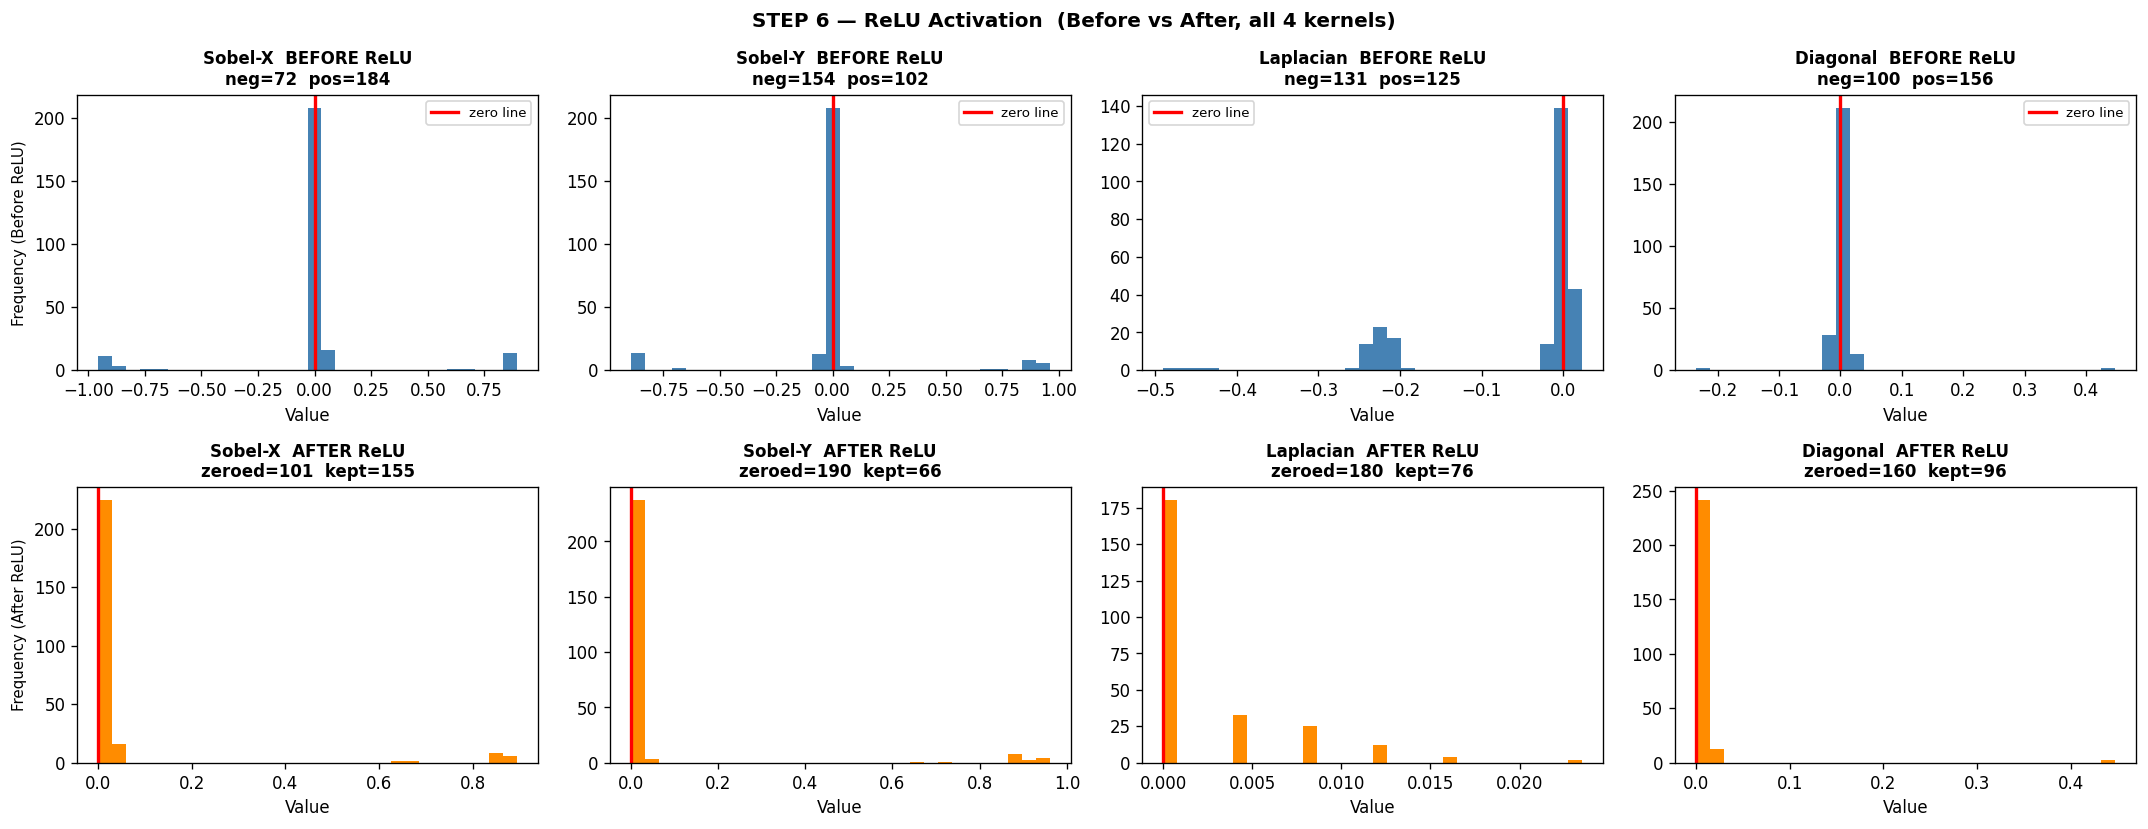

ReLU formula: f(x) = max(0, x)
Effect: all negative convolution responses are zeroed out.
Reason: negative edges are not useful for measuring texture chaos.


In [10]:
# Apply all 4 kernels and show before/after ReLU for each
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('STEP 6 — ReLU Activation  (Before vs After, all 4 kernels)', fontweight='bold')

for col, (kernel, name) in enumerate(zip(model.kernels, kernel_names)):
    conv_out  = convolve(patch, kernel)
    after_relu = relu(conv_out)

    # Before ReLU
    neg_count = (conv_out < 0).sum()
    pos_count = (conv_out >= 0).sum()
    axes[0, col].hist(conv_out.flatten(), bins=30, color='steelblue', edgecolor='none')
    axes[0, col].axvline(0, color='red', linewidth=2, label='zero line')
    axes[0, col].set_title(f'{name}  BEFORE ReLU\nneg={neg_count}  pos={pos_count}')
    axes[0, col].set_xlabel('Value')
    axes[0, col].legend(fontsize=8)

    # After ReLU
    zeroed = (after_relu == 0).sum()
    kept   = (after_relu > 0).sum()
    axes[1, col].hist(after_relu.flatten(), bins=30, color='darkorange', edgecolor='none')
    axes[1, col].axvline(0, color='red', linewidth=2)
    axes[1, col].set_title(f'{name}  AFTER ReLU\nzeroed={zeroed}  kept={kept}')
    axes[1, col].set_xlabel('Value')

axes[0,0].set_ylabel('Frequency (Before ReLU)', fontsize=9)
axes[1,0].set_ylabel('Frequency (After ReLU)',  fontsize=9)
plt.tight_layout()
plt.show()

print('ReLU formula: f(x) = max(0, x)')
print('Effect: all negative convolution responses are zeroed out.')
print('Reason: negative edges are not useful for measuring texture chaos.')

---
## STEP 7 — Statistical Feature Extraction
The 4 feature maps get reduced to 2 numbers: mean and variance.

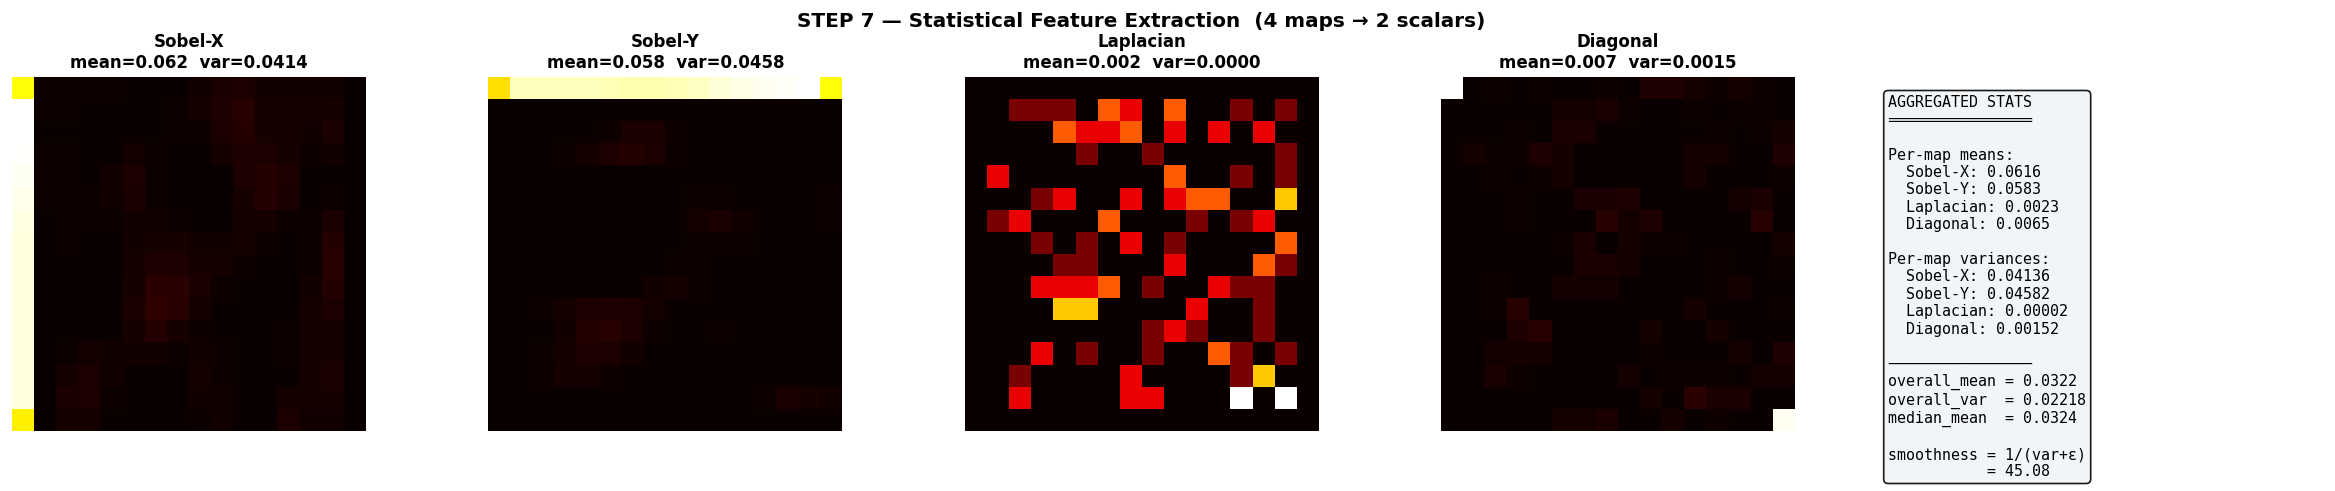

In [11]:
feature_maps = model.forward(patch)
mean_val, var_val, median_val = compute_stats(feature_maps)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('STEP 7 — Statistical Feature Extraction  (4 maps → 2 scalars)', fontweight='bold')

for col, (fm, name) in enumerate(zip(feature_maps, kernel_names)):
    axes[col].imshow(fm, cmap='hot')
    axes[col].set_title(f'{name}\nmean={fm.mean():.3f}  var={fm.var():.4f}')
    axes[col].axis('off')

# Final summary panel
axes[4].axis('off')
summary_text = (
    f'AGGREGATED STATS\n'
    f'════════════════\n\n'
    f'Per-map means:\n'
    + '\n'.join([f'  {n}: {fm.mean():.4f}' for fm, n in zip(feature_maps, kernel_names)])
    + f'\n\nPer-map variances:\n'
    + '\n'.join([f'  {n}: {fm.var():.5f}' for fm, n in zip(feature_maps, kernel_names)])
    + f'\n\n────────────────\n'
    f'overall_mean = {mean_val:.4f}\n'
    f'overall_var  = {var_val:.5f}\n'
    f'median_mean  = {median_val:.4f}\n\n'
    f'smoothness = 1/(var+ε)\n'
    f'           = {1.0/(var_val+1e-6):.2f}'
)
axes[4].text(0.05, 0.95, summary_text, transform=axes[4].transAxes,
             verticalalignment='top', fontfamily='monospace', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.9))

plt.tight_layout()
plt.show()

---
## STEP 8 — Water Score Computation (per patch)
Three cues combined into one scalar water score.

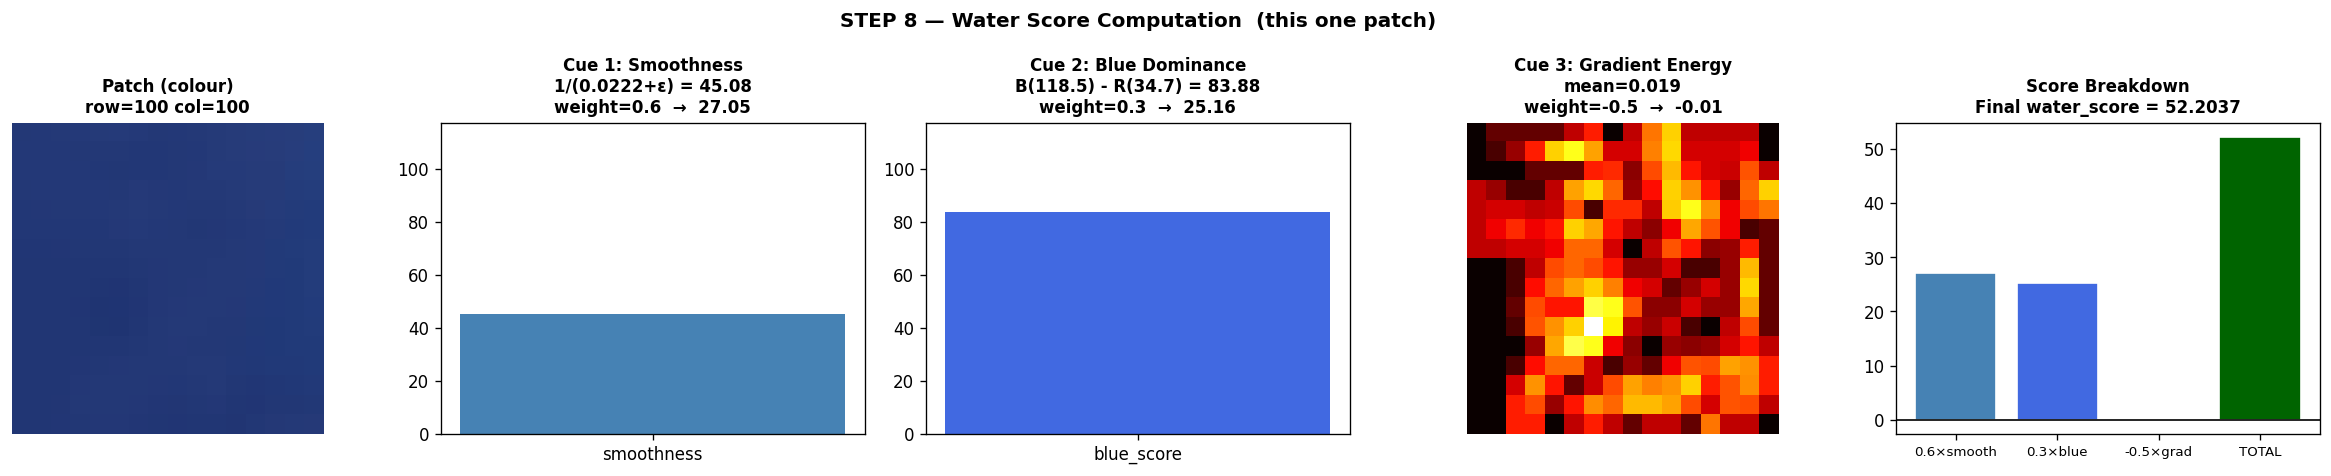

water_score = 0.6×45.083 + 0.3×83.879 - 0.5×0.019 = 52.2037
→  This patch is classified as: WATER


In [12]:
patch_color = color_resized[PATCH_R:PATCH_R+PATCH_SIZE, PATCH_C:PATCH_C+PATCH_SIZE]

# Compute each cue
smoothness    = 1.0 / (var_val + 1e-6)
B_mean        = float(patch_color[:,:,0].mean())
R_mean        = float(patch_color[:,:,2].mean())
blue_score    = max(0.0, B_mean - R_mean)
gx = cv2.Sobel(patch.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(patch.astype(np.float32), cv2.CV_32F, 0, 1, ksize=3)
gradient_energy = float(np.mean(np.sqrt(gx**2 + gy**2)))
water_score   = 0.6 * smoothness + 0.3 * blue_score - 0.5 * gradient_energy

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('STEP 8 — Water Score Computation  (this one patch)', fontweight='bold')

axes[0].imshow(cv2.cvtColor(patch_color, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Patch (colour)\nrow={PATCH_R} col={PATCH_C}')
axes[0].axis('off')

# Cue 1: smoothness bar
axes[1].bar(['smoothness'], [smoothness], color='steelblue')
axes[1].set_title(f'Cue 1: Smoothness\n1/({var_val:.4f}+ε) = {smoothness:.2f}\nweight=0.6  →  {0.6*smoothness:.2f}')
axes[1].set_ylim(0, max(smoothness, blue_score, gradient_energy) * 1.4)

# Cue 2: blue score
axes[2].bar(['blue_score'], [blue_score], color='royalblue')
axes[2].set_title(f'Cue 2: Blue Dominance\nB({B_mean:.1f}) - R({R_mean:.1f}) = {blue_score:.2f}\nweight=0.3  →  {0.3*blue_score:.2f}')
axes[2].set_ylim(0, max(smoothness, blue_score, gradient_energy) * 1.4)

# Cue 3: gradient energy
grad_map = np.sqrt(gx**2 + gy**2)
axes[3].imshow(grad_map, cmap='hot')
axes[3].set_title(f'Cue 3: Gradient Energy\nmean={gradient_energy:.3f}\nweight=-0.5  →  {-0.5*gradient_energy:.2f}')
axes[3].axis('off')

# Final score breakdown
components = ['0.6×smooth', '0.3×blue', '-0.5×grad', 'TOTAL']
values     = [0.6*smoothness, 0.3*blue_score, -0.5*gradient_energy, water_score]
bar_colors = ['steelblue', 'royalblue', 'tomato', 'darkgreen' if water_score > 0 else 'crimson']
axes[4].bar(components, values, color=bar_colors, edgecolor='white')
axes[4].axhline(0, color='black', linewidth=1)
axes[4].set_title(f'Score Breakdown\nFinal water_score = {water_score:.4f}')
axes[4].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()
print(f'water_score = 0.6×{smoothness:.3f} + 0.3×{blue_score:.3f} - 0.5×{gradient_energy:.3f} = {water_score:.4f}')
print(f'→  This patch is classified as: {"WATER" if water_score > 0 else "LAND"}')

---
## STEP 9 — Full Score Map (all patches accumulated)
The same computation applied to every patch across the whole image.

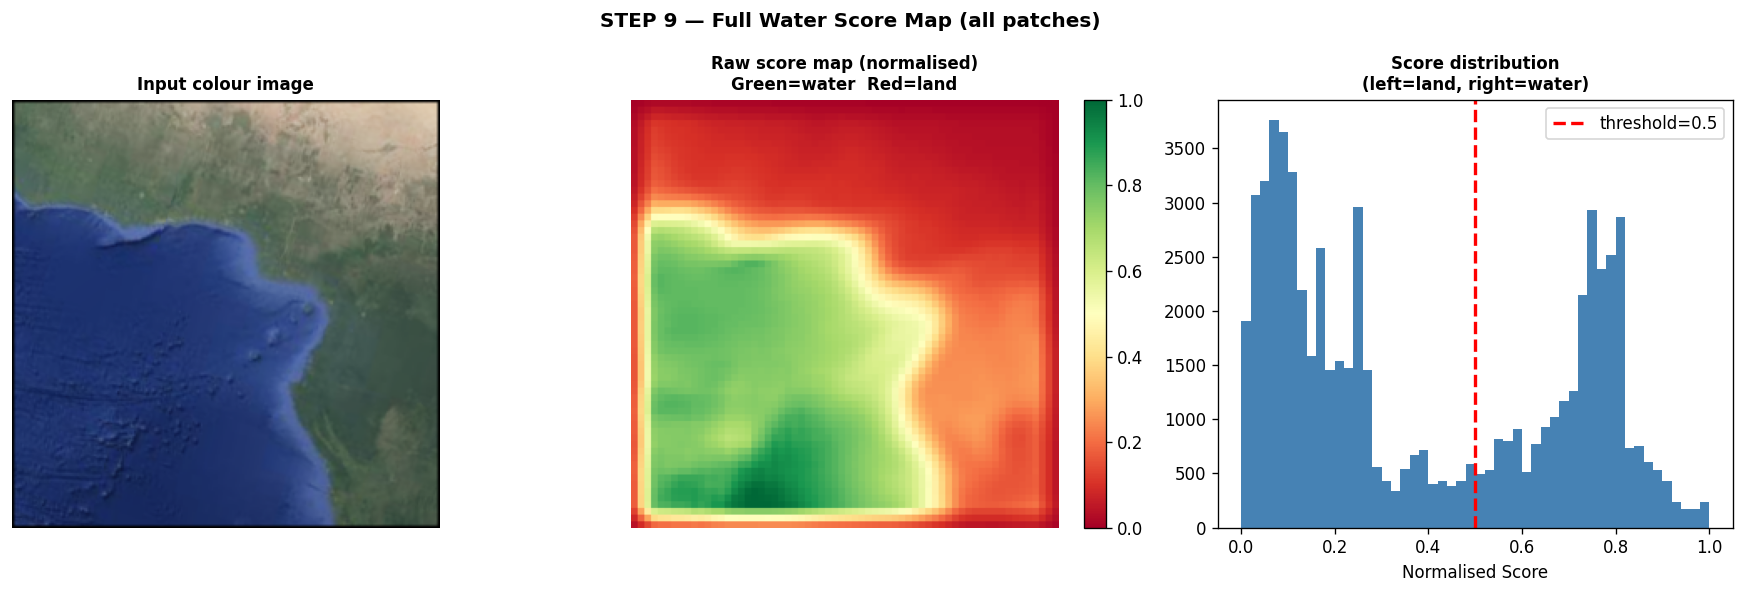

In [13]:
from features.statistics import compute_stats

PATCH_SIZE = 16
stride     = PATCH_SIZE // 4
h, w       = gray_norm.shape
score_map  = np.zeros((h, w), dtype=np.float32)

for i in range(0, h - PATCH_SIZE + 1, stride):
    for j in range(0, w - PATCH_SIZE + 1, stride):
        pg = gray_norm[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
        pc = color_resized[i:i+PATCH_SIZE, j:j+PATCH_SIZE]

        _, var_v, _ = compute_stats(model.forward(pg))
        smooth   = 1.0 / (var_v + 1e-6)
        b_score  = max(0, float(pc[:,:,0].mean()) - float(pc[:,:,2].mean()))
        gx = cv2.Sobel(pg, cv2.CV_32F, 1, 0, ksize=3)
        gy = cv2.Sobel(pg, cv2.CV_32F, 0, 1, ksize=3)
        g_energy = float(np.mean(np.sqrt(gx**2 + gy**2)))
        score_map[i:i+PATCH_SIZE, j:j+PATCH_SIZE] += 0.6*smooth + 0.3*b_score - 0.5*g_energy

score_map_norm = cv2.normalize(score_map, None, 0, 1, cv2.NORM_MINMAX)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('STEP 9 — Full Water Score Map (all patches)', fontweight='bold')

axes[0].imshow(cv2.cvtColor(color_resized, cv2.COLOR_BGR2RGB))
axes[0].set_title('Input colour image')
axes[0].axis('off')

im = axes[1].imshow(score_map_norm, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[1].set_title('Raw score map (normalised)\nGreen=water  Red=land')
axes[1].axis('off')

axes[2].hist(score_map_norm.flatten(), bins=50, color='steelblue', edgecolor='none')
axes[2].axvline(0.5, color='red', linestyle='--', linewidth=2, label='threshold=0.5')
axes[2].set_title('Score distribution\n(left=land, right=water)')
axes[2].set_xlabel('Normalised Score')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## STEP 10 — Threshold → Binary Mask

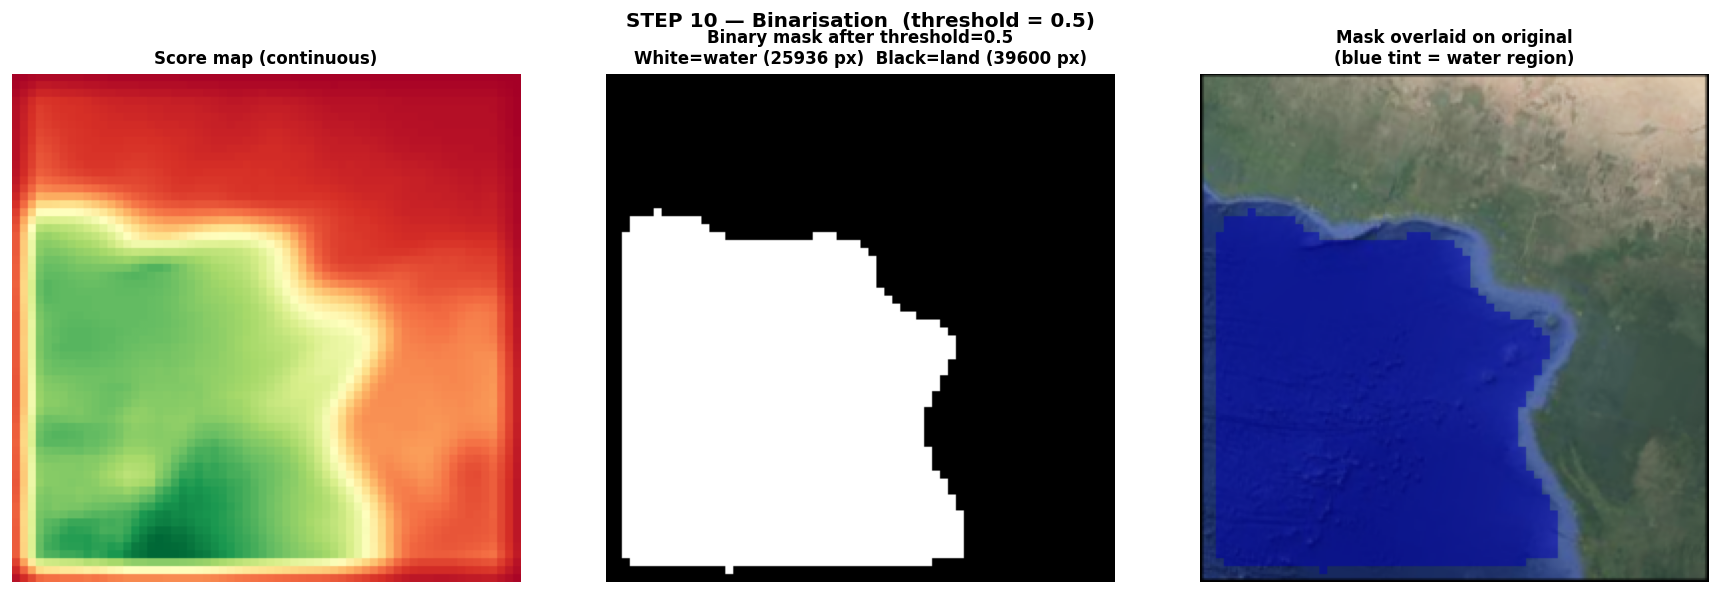

In [14]:
_, mask_raw = cv2.threshold(score_map_norm, 0.5, 1, cv2.THRESH_BINARY)
mask_raw = (mask_raw * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('STEP 10 — Binarisation  (threshold = 0.5)', fontweight='bold')

axes[0].imshow(score_map_norm, cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_title('Score map (continuous)')
axes[0].axis('off')

axes[1].imshow(mask_raw, cmap='gray')
axes[1].set_title(f'Binary mask after threshold=0.5\nWhite=water ({(mask_raw>0).sum()} px)  Black=land ({(mask_raw==0).sum()} px)')
axes[1].axis('off')

# Overlay mask on colour image
overlay = cv2.cvtColor(color_resized, cv2.COLOR_BGR2RGB).copy().astype(float)
overlay[mask_raw > 0] = overlay[mask_raw > 0] * 0.5 + np.array([0, 0, 180]) * 0.5
axes[2].imshow(overlay.astype(np.uint8))
axes[2].set_title('Mask overlaid on original\n(blue tint = water region)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

---
## STEP 11 — Keep Largest Connected Component

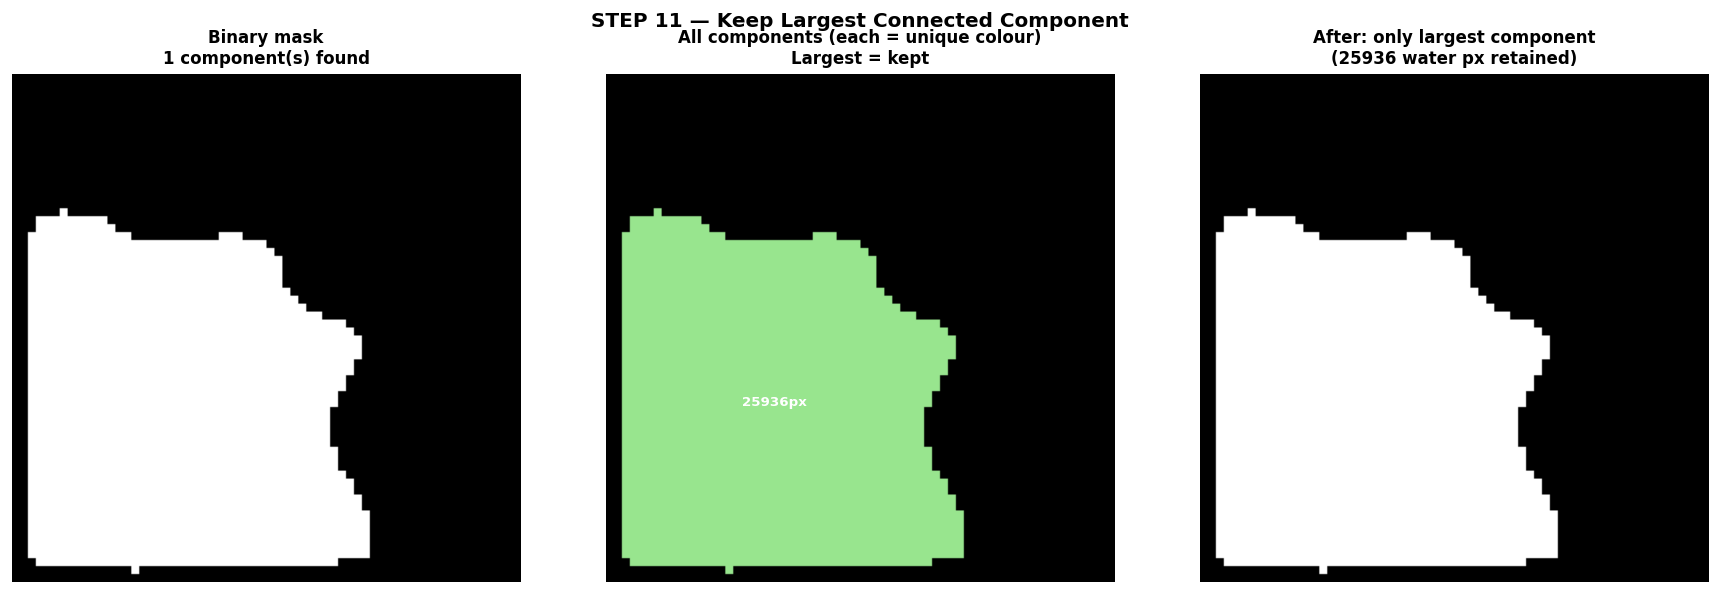

Components found: 1
Sizes: [25936]


In [15]:
num_labels, labels = cv2.connectedComponents(mask_raw)
areas = sorted([(l, int(np.sum(labels==l))) for l in range(1, num_labels)],
               key=lambda x: x[1], reverse=True)

# Colourful label map
label_display = np.zeros((*labels.shape, 3), dtype=np.uint8)
np.random.seed(42)
for lbl, area in areas:
    color = np.random.randint(50, 255, 3)
    label_display[labels == lbl] = color

clean_mask = np.zeros_like(mask_raw)
if areas:
    clean_mask[labels == areas[0][0]] = 255

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('STEP 11 — Keep Largest Connected Component', fontweight='bold')

axes[0].imshow(mask_raw, cmap='gray')
axes[0].set_title(f'Binary mask\n{num_labels-1} component(s) found')
axes[0].axis('off')

axes[1].imshow(label_display)
axes[1].set_title('All components (each = unique colour)\nLargest = kept')
for i, (lbl, area) in enumerate(areas[:5]):
    pos = np.argwhere(labels == lbl)
    cy, cx = pos.mean(axis=0)
    axes[1].text(cx, cy, f'{area}px', fontsize=8, ha='center', color='white', fontweight='bold')
axes[1].axis('off')

axes[2].imshow(clean_mask, cmap='gray')
axes[2].set_title(f'After: only largest component\n({(clean_mask>0).sum()} water px retained)')
axes[2].axis('off')

plt.tight_layout()
plt.show()
print(f'Components found: {num_labels-1}')
print(f'Sizes: {[a for _,a in areas[:6]]}{ "..." if len(areas)>6 else ""}')

---
## STEP 12 — Morphological Smoothing (Close + Open)

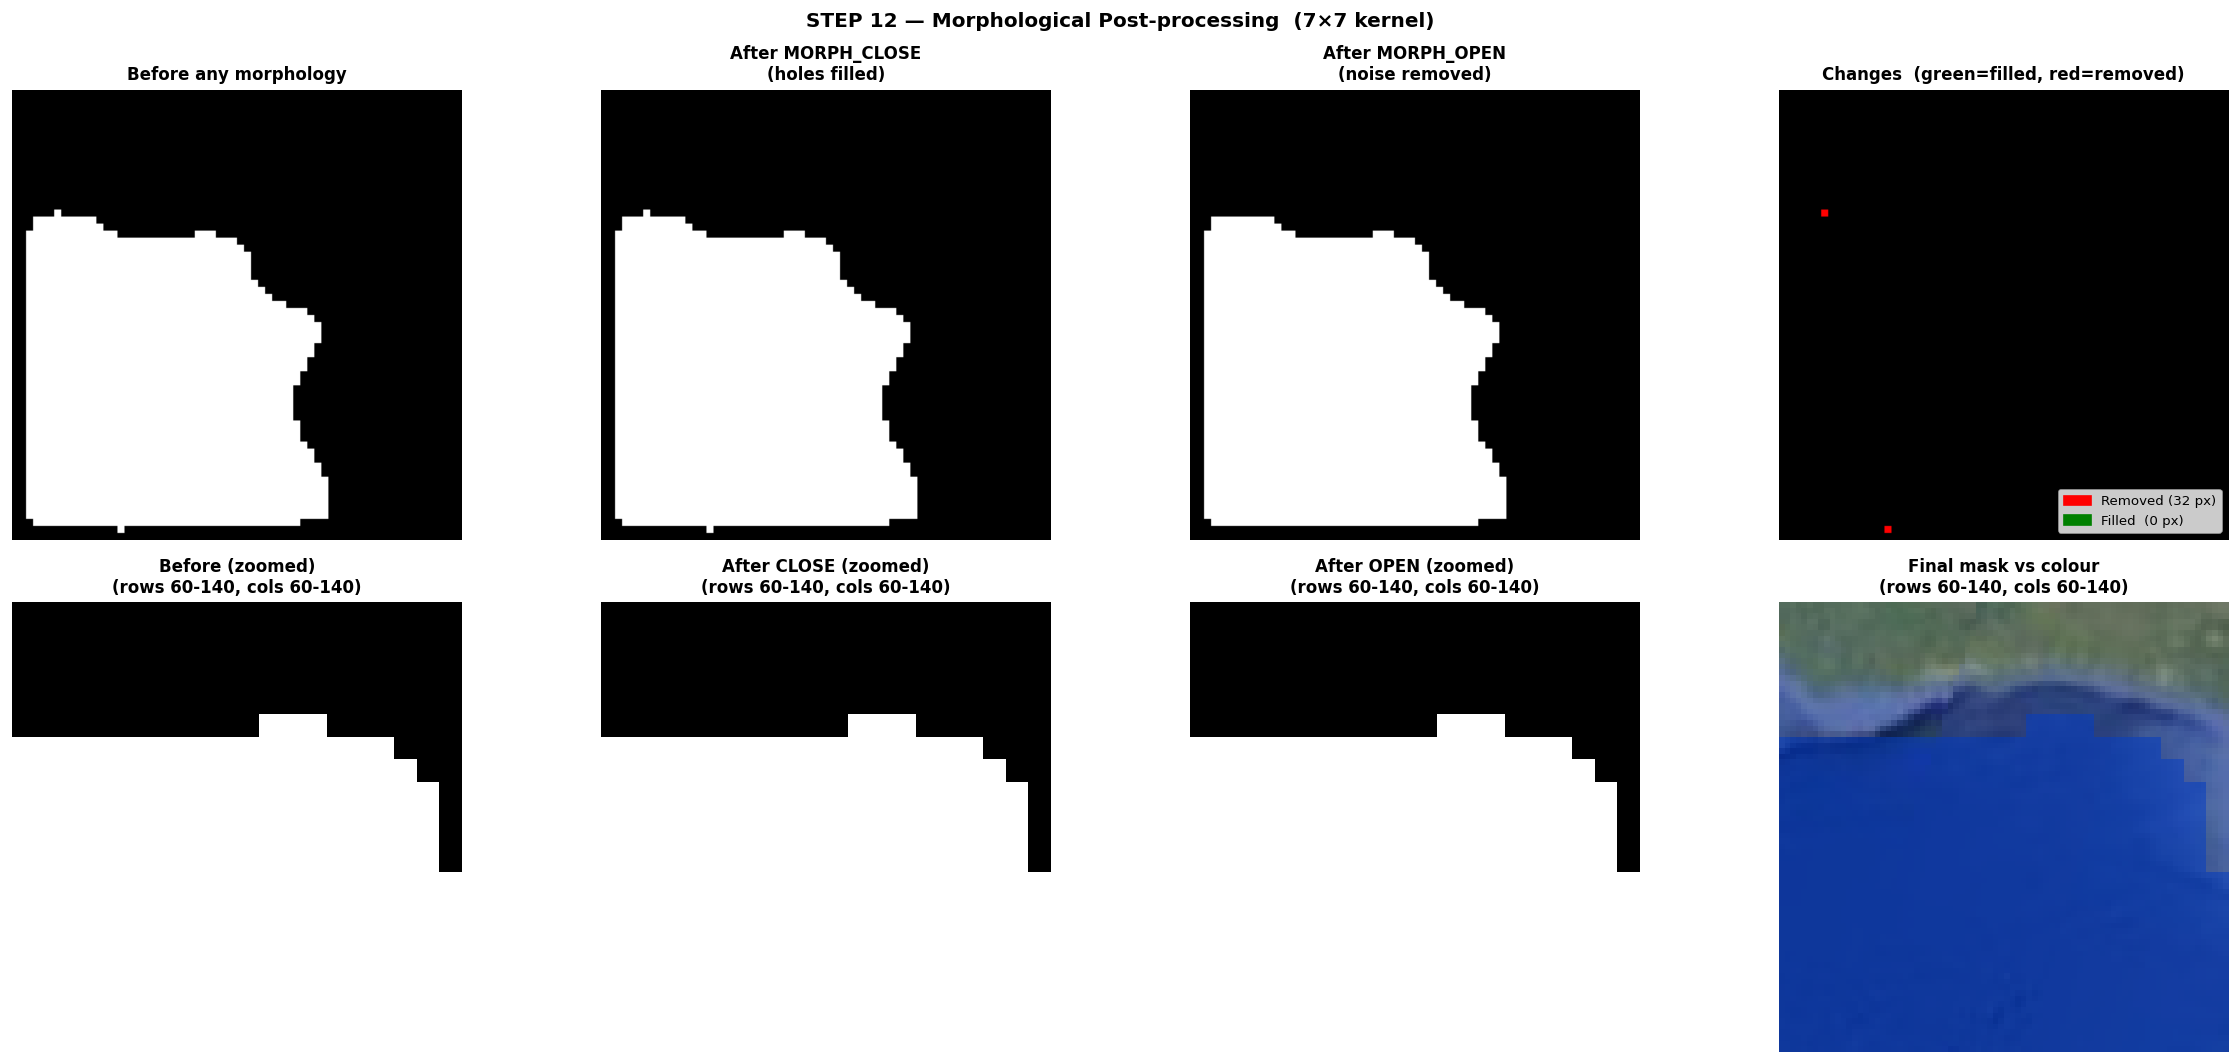

In [16]:
kernel_morph = np.ones((7, 7), np.uint8)
after_close  = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel_morph)
after_open   = cv2.morphologyEx(after_close, cv2.MORPH_OPEN,  kernel_morph)
final_mask   = after_open

# Difference maps
holes_filled = ((after_close > 0) & (clean_mask == 0)).astype(np.uint8) * 255
noise_removed = ((clean_mask > 0) & (after_open == 0)).astype(np.uint8) * 255

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('STEP 12 — Morphological Post-processing  (7×7 kernel)', fontweight='bold')

axes[0,0].imshow(clean_mask, cmap='gray')
axes[0,0].set_title('Before any morphology')
axes[0,0].axis('off')

axes[0,1].imshow(after_close, cmap='gray')
axes[0,1].set_title('After MORPH_CLOSE\n(holes filled)')
axes[0,1].axis('off')

axes[0,2].imshow(after_open, cmap='gray')
axes[0,2].set_title('After MORPH_OPEN\n(noise removed)')
axes[0,2].axis('off')

# Diff
diff_rgb = np.stack([noise_removed, holes_filled, np.zeros_like(clean_mask)], axis=2)
axes[0,3].imshow(diff_rgb)
axes[0,3].set_title('Changes  (green=filled, red=removed)')
r_p = mpatches.Patch(color='red',   label=f'Removed ({(noise_removed>0).sum()} px)')
g_p = mpatches.Patch(color='green', label=f'Filled  ({(holes_filled>0).sum()} px)')
axes[0,3].legend(handles=[r_p, g_p], fontsize=8, loc='lower right')
axes[0,3].axis('off')

# Show zoomed region to see effect clearly
ZOOM = (60, 140, 60, 140)
r1,r2,c1,c2 = ZOOM
for col_idx, (title, img) in enumerate([
    ('Before (zoomed)', clean_mask),
    ('After CLOSE (zoomed)', after_close),
    ('After OPEN (zoomed)', after_open),
    ('Final mask vs colour', None)
]):
    if img is not None:
        axes[1, col_idx].imshow(img[r1:r2, c1:c2], cmap='gray')
    else:
        overlay = cv2.cvtColor(color_resized, cv2.COLOR_BGR2RGB).copy().astype(float)
        overlay[final_mask > 0] = overlay[final_mask > 0] * 0.5 + np.array([0, 60, 200]) * 0.5
        axes[1, col_idx].imshow(overlay.astype(np.uint8)[r1:r2, c1:c2])
    axes[1, col_idx].set_title(f'{title}\n(rows {r1}-{r2}, cols {c1}-{c2})')
    axes[1, col_idx].axis('off')

plt.tight_layout()
plt.show()

---
## STEP 13 — Contour Extraction & Red Boundary Overlay

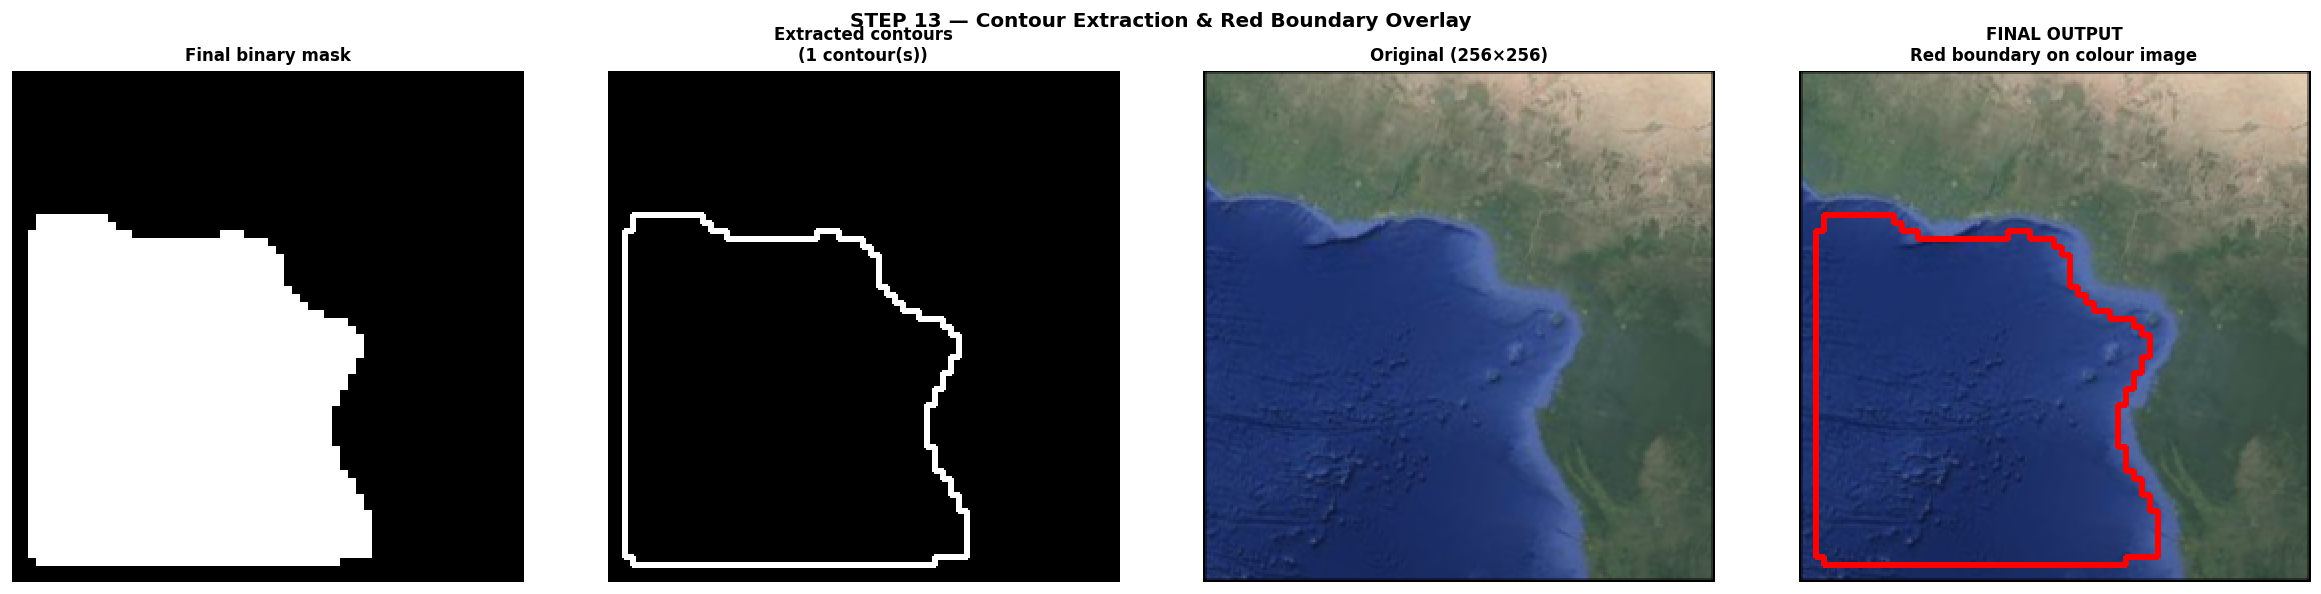

Contours found: 1
Total boundary pixels: 2140


In [17]:
contours, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours
result = color_resized.copy()
cv2.drawContours(result, contours, -1, (0, 0, 255), 2)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('STEP 13 — Contour Extraction & Red Boundary Overlay', fontweight='bold')

axes[0].imshow(final_mask, cmap='gray')
axes[0].set_title('Final binary mask')
axes[0].axis('off')

# Contour-only image
contour_only = np.zeros_like(final_mask)
cv2.drawContours(contour_only, contours, -1, 255, 2)
axes[1].imshow(contour_only, cmap='gray')
axes[1].set_title(f'Extracted contours\n({len(contours)} contour(s))')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(color_resized, cv2.COLOR_BGR2RGB))
axes[2].set_title('Original (256×256)')
axes[2].axis('off')

axes[3].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[3].set_title('FINAL OUTPUT\nRed boundary on colour image')
axes[3].axis('off')

plt.tight_layout()
plt.show()
print(f'Contours found: {len(contours)}')
total_boundary_px = int((contour_only > 0).sum())
print(f'Total boundary pixels: {total_boundary_px}')

---
## FINAL — Complete Pipeline Summary

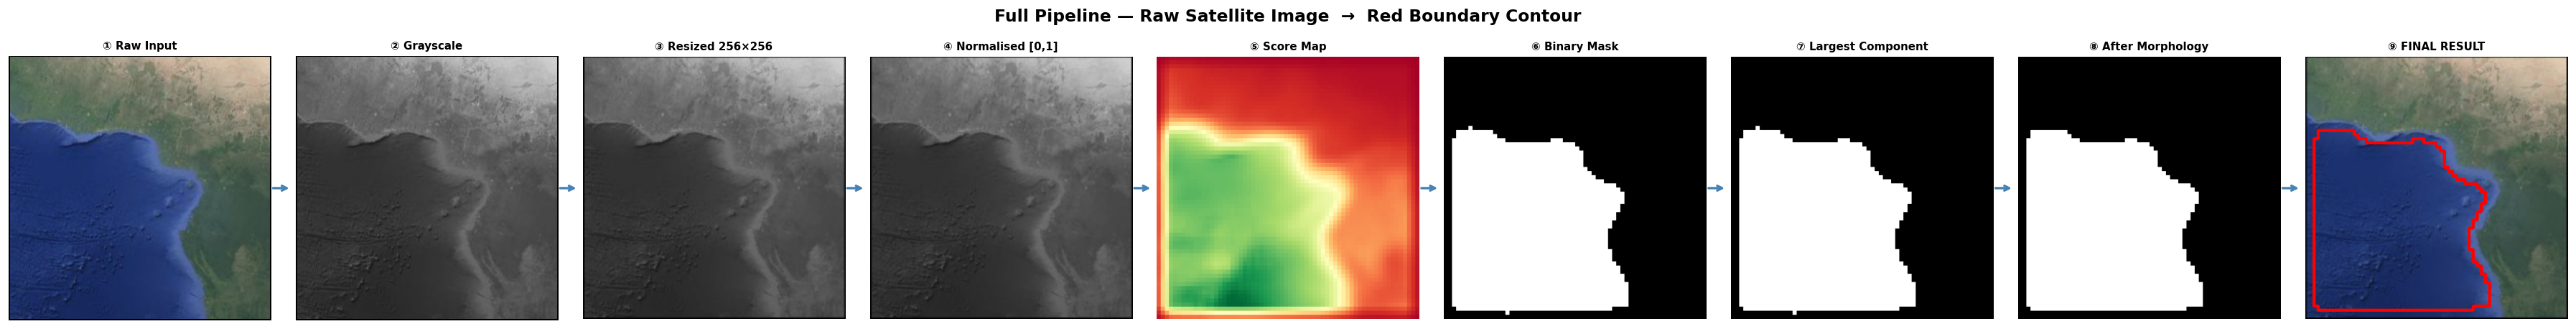

In [18]:
stages = [
    ('① Raw Input',           cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)),
    ('② Grayscale',           gray_raw),
    ('③ Resized 256×256',     gray_resized),
    ('④ Normalised [0,1]',    (gray_norm * 255).astype(np.uint8)),
    ('⑤ Score Map',           (score_map_norm * 255).astype(np.uint8)),
    ('⑥ Binary Mask',         mask_raw),
    ('⑦ Largest Component',   clean_mask),
    ('⑧ After Morphology',    final_mask),
    ('⑨ FINAL RESULT',        cv2.cvtColor(result, cv2.COLOR_BGR2RGB)),
]

cmaps = [None, 'gray', 'gray', 'gray', 'RdYlGn', 'gray', 'gray', 'gray', None]

fig, axes = plt.subplots(1, 9, figsize=(30, 4))
fig.suptitle('Full Pipeline — Raw Satellite Image  →  Red Boundary Contour', fontsize=14, fontweight='bold')

for ax, (title, img), cmap in zip(axes, stages, cmaps):
    kwargs = {'cmap': cmap} if cmap else {}
    if img.ndim == 2:
        kwargs['vmin'] = 0; kwargs['vmax'] = 255
    ax.imshow(img, **kwargs)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
    if title != '⑨ FINAL RESULT':
        ax.annotate('', xy=(1.08, 0.5), xytext=(1.0, 0.5),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))

plt.tight_layout()
plt.show()